<a href="https://colab.research.google.com/github/durgeshchavan25-svg/Data_Science_Lab/blob/main/practicalno8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== Dataset Preview =====
   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  

===== Dataset Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64

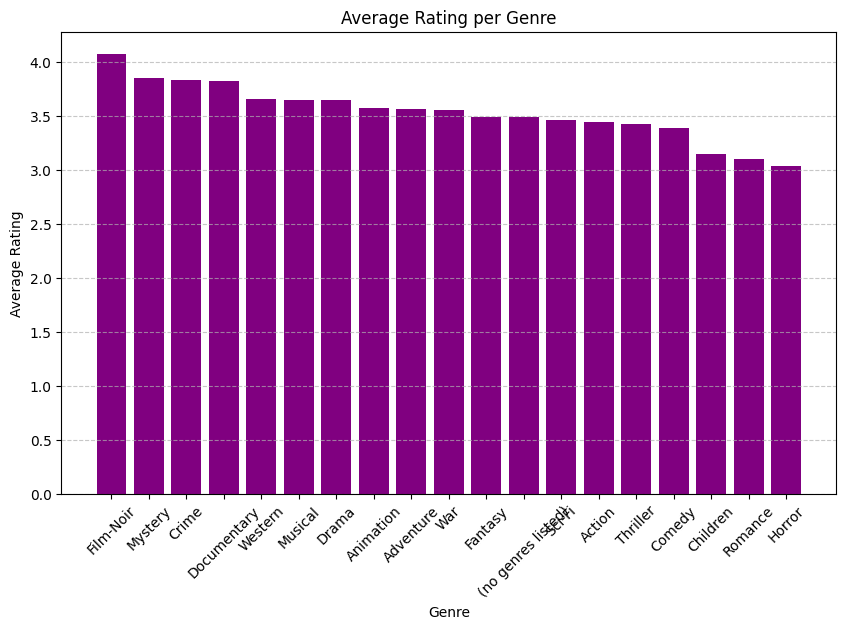


===== Regression Results =====
MSE: 0.9317936049682665
RMSE: 0.9652945690141774
R2 Score: 0.1529463491113462

===== Classification Results =====
Accuracy: 0.6586671955573186

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.51      0.54      7829
           1       0.71      0.75      0.73     12339

    accuracy                           0.66     20168
   macro avg       0.64      0.63      0.63     20168
weighted avg       0.65      0.66      0.65     20168



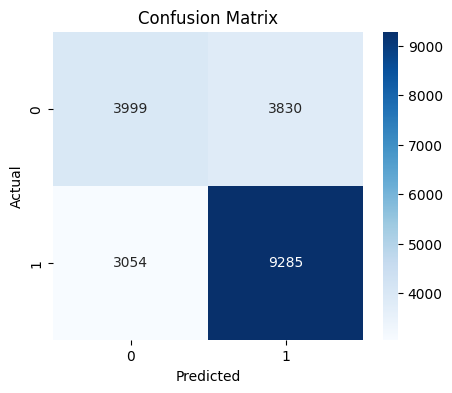

In [29]:
# ================================
# MOVIE RECOMMENDATION EXPERIMENT
# ================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import io

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix, r2_score

# Step 2: Load Dataset
zip_path = "/content/ml-latest-small.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('ml-latest-small/ratings.csv') as f:
        ratings = pd.read_csv(f)
    with z.open('ml-latest-small/movies.csv') as f:
        movies = pd.read_csv(f)

# Merge datasets
data = pd.merge(ratings, movies, on="movieId")

print("\n===== Dataset Preview =====")
print(data.head())

# Step 3: Explore Data
print("\n===== Dataset Info =====")
print(data.info())

# ================================
# Graph: Genre vs Average Rating
# (X = Genre, Y = Avg Rating)
# ================================

# Extract main genre
data['main_genre'] = data['genres'].apply(lambda x: x.split('|')[0])

# Compute average rating
genre_rating = data.groupby('main_genre')['rating'].mean().sort_values(ascending=False)

# Plot (VERTICAL BAR GRAPH)
plt.figure(figsize=(10,6))
plt.bar(genre_rating.index, genre_rating.values, color='purple')

plt.title("Average Rating per Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# ================================
# Step 4: Preprocessing
# ================================
data['genres'] = data['genres'].astype('category').cat.codes

# Features and Target (Regression)
X = data[['userId', 'movieId', 'genres']]
y_reg = data['rating']

# Step 5: Train-Test Split (Regression)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Step 6: Train Regression Model
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train, y_train)

# Predictions
y_pred = reg.predict(X_test)

# Step 7: Evaluate Regression
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===== Regression Results =====")
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ================================
# Classification Part
# ================================

# Step 8: Convert to Classification
data['rating_class'] = np.where(data['rating'] >= 3.5, 1, 0)
y_cls = data['rating_class']

# Step 9: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42
)

# Step 10: Train Classification Model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred_cls = clf.predict(X_test)

# Step 11: Evaluate Classification
print("\n===== Classification Results =====")
print("Accuracy:", accuracy_score(y_test, y_pred_cls))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cls))

# ================================
# Confusion Matrix
# ================================
cm = confusion_matrix(y_test, y_pred_cls)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ================================
# END OF EXPERIMENT
# ================================